In [219]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import requests

from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture

In [4]:
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [165]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [186]:
t90 = np.array(data[6], dtype=float)
t100 = np.array(data[12], dtype=float)
fluence = np.array(data[9], dtype=float)
redshift = np.array(data[11], dtype=float)

In [178]:
fluence_clean = fluence[((fluence != -999) & (t90 != -999) & (fluence != 0))]
t90_clean = t90[((fluence != -999) & (t90 != -999) & (fluence != 0))]

In [179]:
fluence_100_clean = fluence[((fluence != -999) & (t100 != -999) & (fluence != 0))]
t100_clean = t100[((fluence != -999) & (t100 != -999) & (fluence != 0))]

In [204]:
redshift_clean = redshift[((redshift != -999) & (t90 != -999) & (fluence > 0))]
t90_r_clean = t90[((redshift != -999) & (t90 != -999) & (fluence > 0))]
fluence_r_clean = fluence[((redshift != -999) & (t90 != -999) & (fluence > 0))]

In [212]:
grb = dict(zip(names,data))
for lab in ['T90',"redshift","T90_error"]:
    grb[lab] = np.array(grb[lab],dtype='float')

Text(0.5, 0, 't [s]')

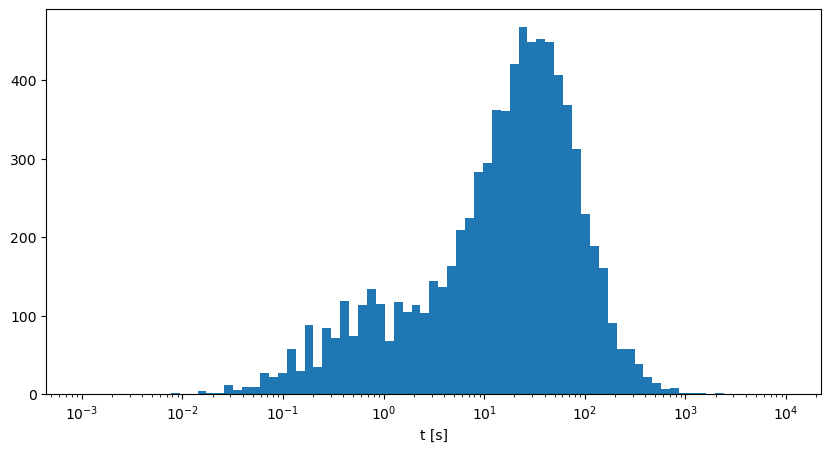

In [225]:
fig,ax = plt.subplots(figsize=(10,5))
plt.hist(grb['T90'],bins= np.logspace(-3,4,80))
plt.xscale('log')
plt.xlabel('t [s]')

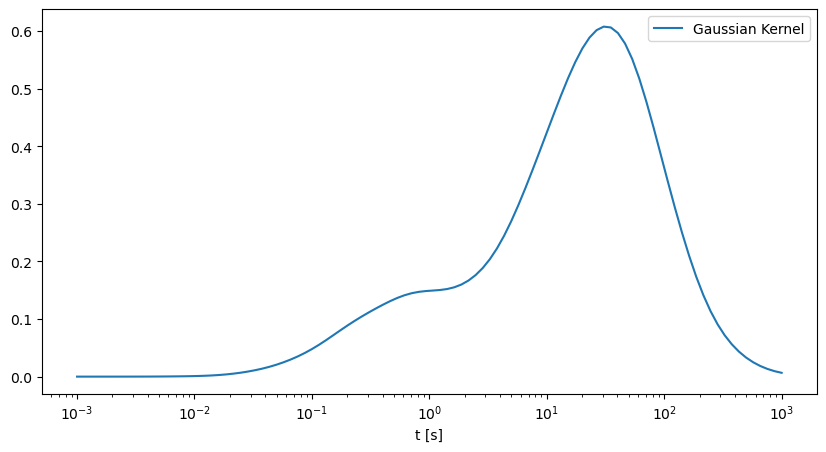

In [252]:
lt90_clean = np.log10(t90_clean)
skt90_clean = lt90_clean[:,np.newaxis]

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(skt90_clean)
xgrid = np.logspace(-3,3,100)

# Rememember score_samples is the log-likelohood. Neep an exp in front
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

fig,ax = plt.subplots(figsize=(10,5))

plt.xlabel('t [s]')
plt.plot(xgrid,ygrid,label='Gaussian Kernel')
plt.xscale('log')
plt.legend()

Text(0, 0.5, 'fluence')

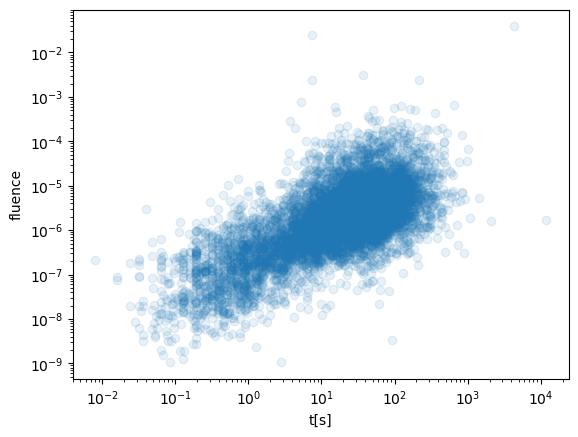

In [203]:
plt.scatter(t100_clean,fluence_100_clean,alpha=0.1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('t[s]')
plt.ylabel('fluence')

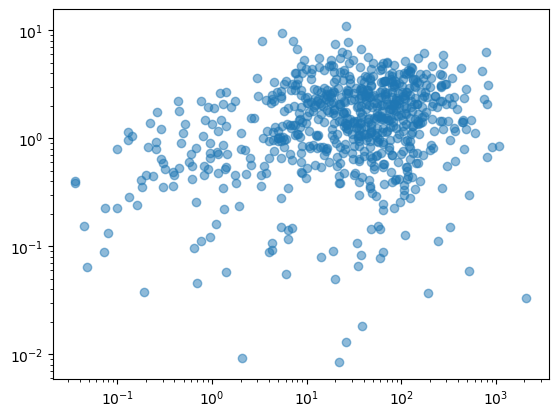

In [189]:
plt.scatter(t90_r_clean,redshift_clean,alpha=0.5)
plt.xscale('log')
plt.yscale('log')

K-Means
-

Text(0, 0.5, 'log(fluence [$erg/cm^2\t$])')

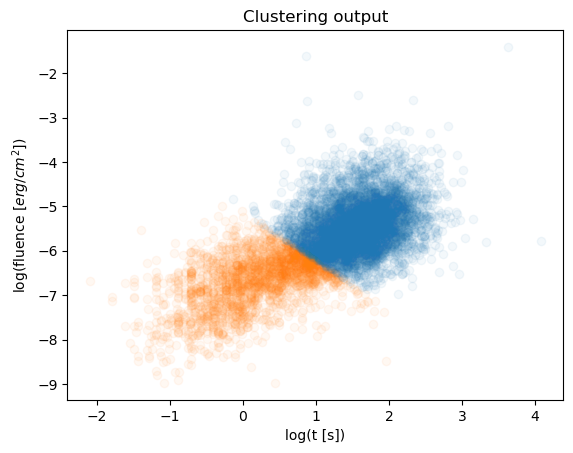

In [295]:
X = np.array([np.log10(t100_clean), np.log10(fluence_100_clean)])
X = X.T
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.05)

plt.title(r'Clustering output')

plt.xlabel('log(t [s])')
plt.ylabel(r'log(fluence [$erg/cm^2	$])')

In [296]:
centers = 10**np.squeeze(centers)
edge = 10**( np.mean( [max(X[labels==0,0]), min(X[labels==1,0]) ]))

[[1.50538357e+00 2.01927353e-07]
 [3.71023403e+01 3.70180960e-06]]


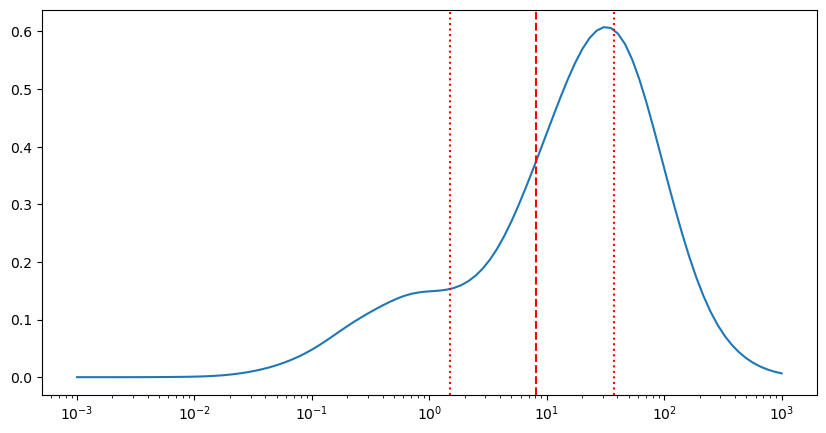

In [297]:
fig,ax = plt.subplots(figsize=(10,5))

plt.plot(xgrid,ygrid)
plt.semilogx()
for v in centers:
    plt.axvline(v[0], c='red',ls='dotted')
plt.axvline(edge,c='red',ls='dashed')
print(centers)

[]

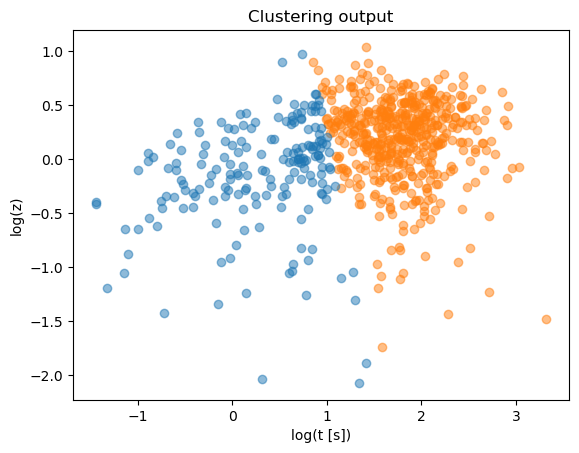

In [298]:
Y = np.array([np.log10(t90_r_clean), np.log10(redshift_clean)])
Y = Y.T
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(Y)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(Y) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(Y[labels==ii,0], Y[labels==ii,1], 
                color=colors[ii],alpha=0.5)

plt.title(r'Clustering output')

plt.xlabel('log(t [s])')
plt.ylabel(r'log(z)')
plt.plot()

In [299]:
centers = 10**np.squeeze(centers)
edge = 10**( np.mean( [max(Y[labels==0,0]), min(Y[labels==1,0]) ]))

[[61.65726017  1.55642454]
 [ 1.98506908  0.71586579]]


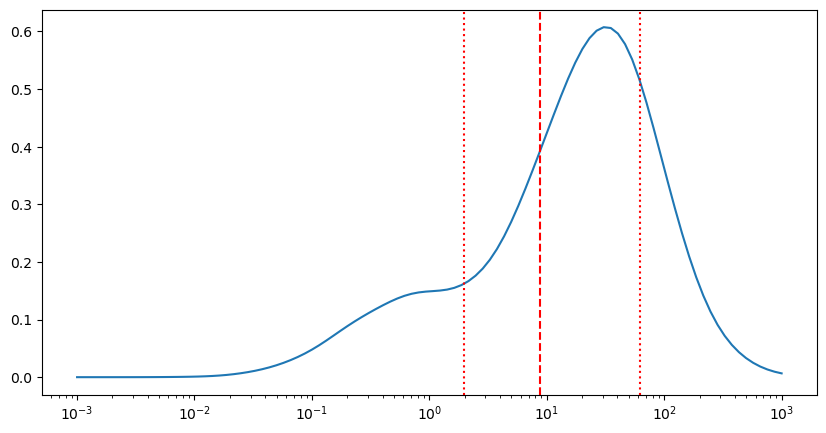

In [300]:
fig,ax = plt.subplots(figsize=(10,5))

plt.plot(xgrid,ygrid)
plt.semilogx()
for v in centers:
    plt.axvline(v[0], c='red',ls='dotted')
plt.axvline(edge,c='red',ls='dashed')
print(centers)

[]

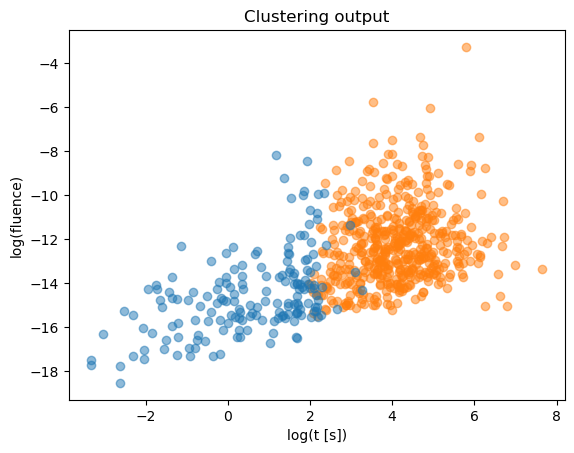

In [210]:
for ii in range(3):
    plt.scatter(Y[labels==ii,0], np.log(fluence_r_clean[labels==ii]), 
                color=colors[ii],alpha=0.5)

plt.title(r'Clustering output')

plt.xlabel('log(t [s])')
plt.ylabel(r'log(fluence)')
plt.plot()

Mean shift
-

In [184]:
from sklearn.cluster import MeanShift

scaler = preprocessing.StandardScaler()
bandwidth = 0.4
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform(X))

MeanShift(bandwidth=0.4, bin_seeding=True, cluster_all=False)

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
0.4
number of estimated clusters : 23


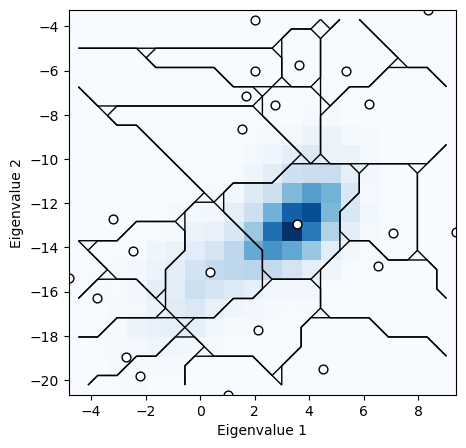

In [185]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 20)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 20 * 20)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((20, 20))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((20, 20))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()    